# LSTM – Human Activity Recognition

This notebook trains and evaluates three LSTM candidate architectures
on the preprocessed UCI HAR dataset, selects the best one based on
validation performance, and reports final test-set metrics.

**Dev: Dewmini**

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


DATASET_NAME = "har_processed.npz"
REMOTE_DATASET_URL = (
    "https://raw.githubusercontent.com/"
    "SLIIT-Y4-S2-DL-ORG/Deep-Learning-Assignment/"
    "main/processed_Data/har_processed.npz"
)

search_roots = []

for value in [
    Path.cwd(),
    Path(os.environ.get("PWD", "")),
    Path("/workspace"),
    Path("/workspaces"),
    Path("/mnt/data"),
    Path("/home/oai/share"),
    Path("/tmp")
]:
    if value.exists() and value not in search_roots:
        search_roots.append(value)

candidate_files = []

for root in search_roots:
    for parent in [root, *root.parents]:
        candidate_files.append(
            parent / "processed_Data" / DATASET_NAME
        )

    if root != Path("/"):
        candidate_files.extend(
            root.glob(
                f"**/processed_Data/{DATASET_NAME}"
            )
        )

DATA_FILE = next(
    (
        path.resolve()
        for path in candidate_files
        if path.is_file()
    ),
    None
)

if DATA_FILE is None:
    download_dir = Path.cwd() / "processed_Data"
    download_dir.mkdir(parents=True, exist_ok=True)
    download_file = download_dir / DATASET_NAME

    print("Local dataset not found.")
    print("Downloading the committed processed dataset...")

    try:
        urlretrieve(REMOTE_DATASET_URL, download_file)
    except Exception as error:
        raise FileNotFoundError(
            "The processed dataset is not visible to this kernel and "
            "could not be downloaded. Select a local Python kernel or "
            "upload processed_Data/har_processed.npz to this kernel."
        ) from error

    if not download_file.is_file():
        raise FileNotFoundError(
            f"Dataset download failed: {download_file}"
        )

    DATA_FILE = download_file.resolve()
    print("Downloaded dataset:", DATA_FILE)

PROJECT_ROOT = DATA_FILE.parent.parent

print("Processed dataset:", DATA_FILE)
print("Project root:", PROJECT_ROOT)
print("Processed dataset found.")

Processed dataset: /content/processed_Data/har_processed.npz
Project root: /content
Processed dataset found.


In [ ]:
data = np.load(DATA_FILE)

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

activity_names = data[
    "activity_names"
]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nLabels")
print("Train:", np.unique(y_train))
print("Validation:", np.unique(y_val))
print("Test:", np.unique(y_test))

print("\nActivities:")
print(activity_names)

Train: (5551, 128, 9)
Validation: (1801, 128, 9)
Test: (2947, 128, 9)

Labels
Train: [0 1 2 3 4 5]
Validation: [0 1 2 3 4 5]
Test: [0 1 2 3 4 5]

Activities:
['Walking' 'Walking Upstairs' 'Walking Downstairs' 'Sitting' 'Standing'
 'Laying']


In [ ]:
assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1:] == (128, 9)
assert X_val.shape[1:] == (128, 9)
assert X_test.shape[1:] == (128, 9)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert np.array_equal(
    np.unique(y_train),
    np.arange(6)
), "Training labels must be 0-5"

assert np.array_equal(
    np.unique(y_val),
    np.arange(6)
), "Validation labels must be 0-5"

assert np.array_equal(
    np.unique(y_test),
    np.arange(6)
), "Test labels must be 0-5"

print("All dataset checks passed.")

All dataset checks passed.


## LSTM input shape

Unlike the MLP (which flattens each window to 1 152 features),
the LSTM **keeps** the 3-D shape `(samples, 128, 9)` so it can
process the 128 time-steps sequentially and learn temporal
dependencies across the sensor channels.

In [ ]:
N_TIMESTEPS = X_train.shape[1]   # 128
N_CHANNELS = X_train.shape[2]    # 9
N_CLASSES = len(np.unique(y_train))  # 6

print(f"Timesteps : {N_TIMESTEPS}")
print(f"Channels  : {N_CHANNELS}")
print(f"Classes   : {N_CLASSES}")

Timesteps : 128
Channels  : 9
Classes   : 6


## Candidate architectures

Three LSTM variants of increasing capacity are compared.
Each architecture is a list of LSTM hidden-unit sizes;
when more than one value is given the earlier LSTM layers
return sequences to feed the next LSTM layer.

In [ ]:
LSTM_CANDIDATES = {
    "LSTM_A_Small":  [64],
    "LSTM_B_Medium": [128, 64],
    "LSTM_C_Large":  [256, 128]
}

LSTM_CANDIDATES

{'LSTM_A_Small': [64], 'LSTM_B_Medium': [128, 64], 'LSTM_C_Large': [256, 128]}

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM as KerasLSTM,
    Dense,
    Dropout,
    BatchNormalization
)


def build_lstm(lstm_layers):
    model = Sequential()

    model.add(
        Input(
            shape=(N_TIMESTEPS, N_CHANNELS)
        )
    )

    for i, units in enumerate(lstm_layers):
        return_seq = i < len(lstm_layers) - 1

        model.add(
            KerasLSTM(
                units,
                return_sequences=return_seq
            )
        )

        model.add(
            BatchNormalization()
        )

        model.add(
            Dropout(0.30)
        )

    model.add(
        Dense(
            N_CLASSES,
            activation="softmax"
        )
    )

    return model

In [ ]:
from tensorflow.keras.optimizers import Adam


def compile_lstm(model):
    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

## Training loop

Identical protocol to the MLP notebook: same seed reset,
same callbacks, same batch size, same max epochs.

In [ ]:
SEED = 42

experiment_results = []
experiment_histories = {}
trained_models = {}

for model_name, lstm_layers in LSTM_CANDIDATES.items():

    print("\n" + "=" * 60)
    print(f"Training {model_name}")
    print("Architecture:", lstm_layers)
    print("=" * 60)

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_lstm(lstm_layers)
    model = compile_lstm(model)

    model.summary()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=100,
        batch_size=64,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=1
    )

    training_time = (
        time.time() - start_time
    )

    best_val_loss, best_val_accuracy = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    epochs_trained = len(
        history.history["loss"]
    )

    parameters = model.count_params()

    experiment_results.append({
        "Model": model_name,
        "Architecture": str(lstm_layers),
        "Best Validation Accuracy":
            best_val_accuracy,
        "Best Validation Loss":
            best_val_loss,
        "Parameters":
            parameters,
        "Training Time (s)":
            training_time,
        "Epochs Trained":
            epochs_trained
    })

    experiment_histories[
        model_name
    ] = history.history

    trained_models[
        model_name
    ] = model


Training LSTM_A_Small
Architecture: [64]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,590 (76.52 KB)

 Trainable params: 19,462 (76.02 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 256)       │       272,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,814 (1.80 MB)

 Trainable params: 471,046 (1.80 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 65s 717ms/step - accuracy: 0.8215 - loss: 0.4618 - val_accuracy: 0.8340 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 80s 690ms/step - accuracy: 0.9159 - loss: 0.2015 - val_accuracy: 0.9023 - val_loss: 0.2904 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 60s 695ms/step - accuracy: 0.9317 - loss: 0.1541 - val_accuracy: 0.9373 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 82s 711ms/step - accuracy: 0.9342 - loss: 0.1564 - val_accuracy: 0.9506 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 80s 689ms/step - accuracy: 0.9389 - loss: 0.1341 - val_accuracy: 0.9311 - val_loss: 0.1598 - learning_rate: 0.0010
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 82s 688ms/step - accuracy: 0.9362 - loss: 0.1382 - val_accuracy: 0.9556 - val_loss: 0.1728 - learning_rate: 0.0010
Epoch 9/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9491 - lo

## Candidate comparison

In [ ]:
results_df = pd.DataFrame(
    experiment_results
)

results_df

,Model,Architecture,Best Validation Accuracy,Best Validation Loss,Parameters,Training Time (s),Epochs Trained
0,LSTM_A_Small,[64],0.952804,0.109030,19590,69.412236,16
1,LSTM_B_Medium,"[128, 64]",0.977235,0.077784,121222,331.286976,14
2,LSTM_C_Large,"[256, 128]",0.951138,0.100117,471814,1018.955958,14


In [ ]:
results_df.sort_values(
    by="Best Validation Accuracy",
    ascending=False
)

,Model,Architecture,Best Validation Accuracy,Best Validation Loss,Parameters,Training Time (s),Epochs Trained
1,LSTM_B_Medium,"[128, 64]",0.977235,0.077784,121222,331.286976,14
0,LSTM_A_Small,[64],0.952804,0.109030,19590,69.412236,16
2,LSTM_C_Large,"[256, 128]",0.951138,0.100117,471814,1018.955958,14


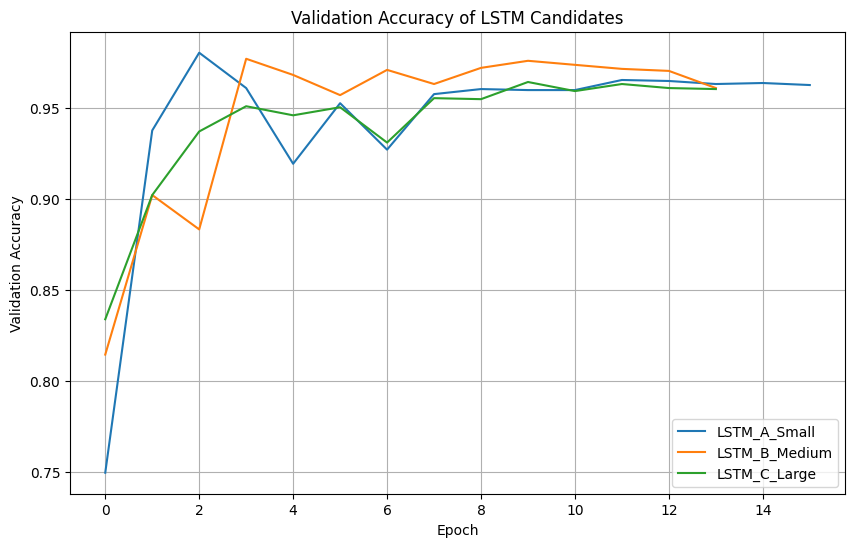

In [ ]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():

    plt.plot(
        history["val_accuracy"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(
    "Validation Accuracy of LSTM Candidates"
)
plt.legend()
plt.grid()

plt.show()

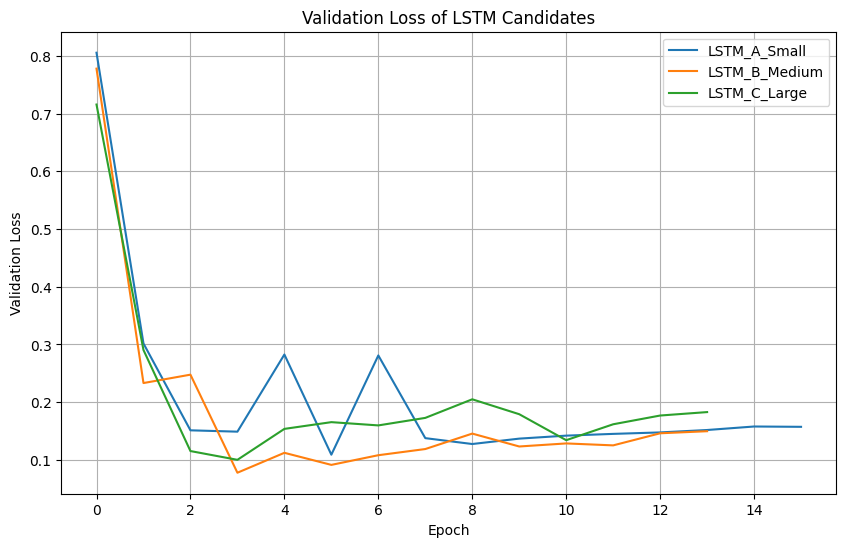

In [ ]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():

    plt.plot(
        history["val_loss"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss of LSTM Candidates"
)
plt.legend()
plt.grid()

plt.show()

## Select best candidate

Pick the candidate with the **lowest validation loss** (with
best-epoch weights already restored by `EarlyStopping`).

In [ ]:
best_idx = results_df[
    "Best Validation Loss"
].idxmin()

FINAL_MODEL_NAME = results_df.loc[
    best_idx, "Model"
]

final_model = trained_models[
    FINAL_MODEL_NAME
]

final_history = experiment_histories[
    FINAL_MODEL_NAME
]

selected_result = results_df.loc[
    results_df["Model"] == FINAL_MODEL_NAME
].iloc[0]

final_training_time = float(
    selected_result["Training Time (s)"]
)

final_epochs_trained = int(
    selected_result["Epochs Trained"]
)

total_parameters = final_model.count_params()

print("Selected model:", FINAL_MODEL_NAME)
print("Parameters:", total_parameters)
print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)

Selected model: LSTM_B_Medium
Parameters: 121222
Training time: 331.29 seconds


## Final model – training curves

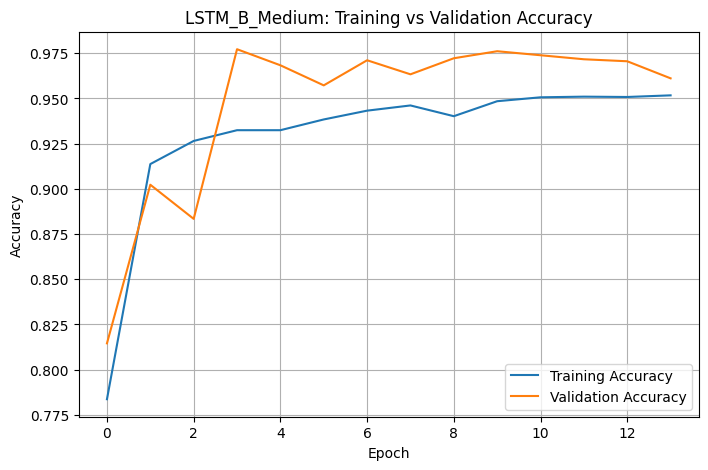

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Accuracy"
)

plt.legend()
plt.grid()
plt.show()

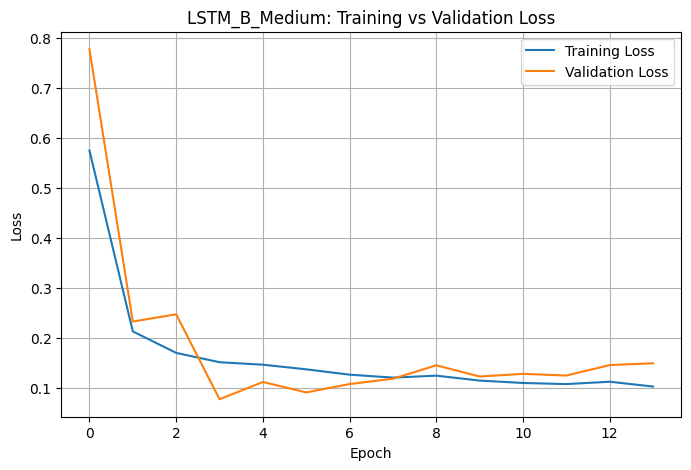

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Loss"
)

plt.legend()
plt.grid()
plt.show()

### Learning-rate schedule

Visualise when `ReduceLROnPlateau` lowered the learning rate
during training of the selected model.

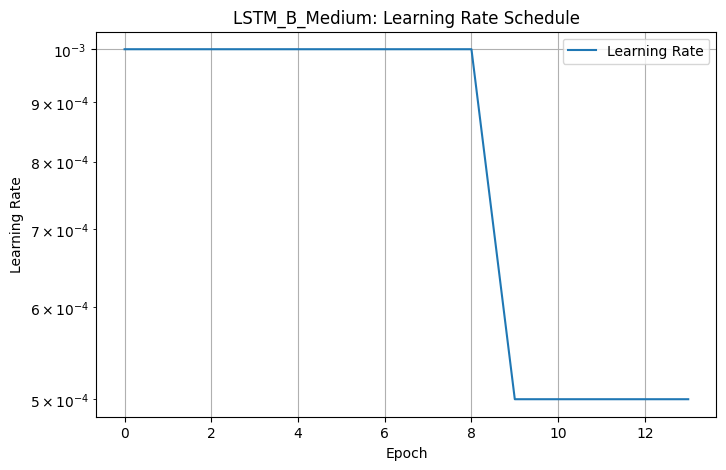

In [ ]:
if "learning_rate" in final_history:
    plt.figure(figsize=(8, 5))

    plt.plot(
        final_history["learning_rate"],
        label="Learning Rate"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(
        f"{FINAL_MODEL_NAME}: Learning Rate Schedule"
    )

    plt.legend()
    plt.grid()
    plt.yscale("log")
    plt.show()
else:
    print(
        "Learning rate history not available "
        "in this TensorFlow version."
    )

## Test-set evaluation

In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


start_inference = time.time()

y_probability = final_model.predict(
    X_test,
    verbose=0
)

inference_time = (
    time.time() - start_inference
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print(
    f"Inference time: "
    f"{inference_time:.4f} seconds"
)

print(
    f"Average inference time per sample: "
    f"{inference_time / len(X_test):.6f} seconds"
)

### Classification report

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_names,
        digits=4
    )
)

### Aggregate metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1:        {f1_weighted:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")

### Per-class F1 bar chart

In [ ]:
per_class_f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    activity_names,
    per_class_f1,
    color="steelblue"
)

for bar, value in zip(bars, per_class_f1):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, 1.1)
plt.ylabel("F1 Score")
plt.title(
    f"{FINAL_MODEL_NAME}: Per-Class F1 Score"
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

### Confusion matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "LSTM Confusion Matrix"
)

plt.show()

### Normalised confusion matrix

Each row is divided by its total so that cells show **recall**
percentages. This makes it easier to compare performance across
activities with different support counts.

In [ ]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp_norm.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2%"
)

plt.title(
    "LSTM Normalised Confusion Matrix"
)

plt.show()

## Save results

In [ ]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "Results"
    / "LSTM"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
results = pd.DataFrame([
    {
        "Model": FINAL_MODEL_NAME,
        "Architecture": str(
            LSTM_CANDIDATES[FINAL_MODEL_NAME]
        ),
        "Accuracy": accuracy,
        "Precision_weighted": precision_weighted,
        "Recall_weighted": recall_weighted,
        "F1_weighted": f1_weighted,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Test_loss": test_loss,
        "Parameters": total_parameters,
        "Training_time_seconds": final_training_time,
        "Inference_time_seconds": inference_time,
        "Epochs_trained": final_epochs_trained
    }
])

results.to_csv(
    RESULTS_DIR / "lstm_results.csv",
    index=False
)

results

In [ ]:
results_df.to_csv(
    RESULTS_DIR
    / "lstm_candidate_comparison.csv",
    index=False
)

print("Candidate comparison saved.")

In [ ]:
history_df = pd.DataFrame(
    final_history
)

history_df.to_csv(
    RESULTS_DIR
    / "lstm_training_history.csv",
    index=False
)

print("Final model training history saved.")

In [ ]:
final_model.save(
    RESULTS_DIR / "lstm_final.keras"
)

print("Final LSTM model saved.")